# 04C — Proton Channel Sensitivity (Checkpoint 4C)

When the monthly high-flux footprint is defined the **same way**, how much do center, area, and
intensity change across NOAA-19 omnidirectional proton channels **p1 / p2 / p3**? Same month
(Jan 2024), region, grids (5°/2°), statistics, thresholds, and coverage masks as CP4A/CP4B.
**Executed on real data — outputs are real.**

> **Cautious scope.** These are *channel-dependent footprints* / *method-dependent high-flux
> regions* / *candidate high-flux sectors*. **Not** a true SAA boundary, danger zone, dose, health
> risk, or discovery. **Absolute flux is NOT directly comparable across channels** (different
> energies) — we compare footprint **location/shape**, not absolute intensity. A higher channel is
> **not** "more dangerous". `mep_IFC_on == -1` remains retained and **uninterpreted**.

In [1]:
import os, sys, pathlib, copy, itertools
import numpy as np, pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

cwd = pathlib.Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(ROOT / "src"))

from saa.aggregate import load_range_channels, build_grid_table, add_coverage_mask
from saa.load_poes import open_poes_netcdf, channel_metadata
from saa.grid_flux import prepare_region, grid_statistics, DEFAULT_LAT_RANGE, DEFAULT_LON_RANGE
from saa.plot_maps import plot_heatmap
from saa.threshold_analysis import (run_channel_sensitivity, coverage_passed,
                                     percentile_threshold, flux_weighted_centroid, haversine_km)

RAW = ROOT / "data" / "raw"; PROC = ROOT / "data" / "processed"
TBL = ROOT / "outputs" / "tables"; FIG = ROOT / "outputs" / "figures"
for d in (PROC, TBL, FIG): d.mkdir(parents=True, exist_ok=True)

CHANNELS = ["mep_omni_flux_p1", "mep_omni_flux_p2", "mep_omni_flux_p3"]
SHORT = {c: c.split("_")[-1] for c in CHANNELS}
LAT, LON = DEFAULT_LAT_RANGE, DEFAULT_LON_RANGE
THRESH = 30           # same coverage threshold as CP4A (sampling-based, identical across channels)
COLORS = {"mep_omni_flux_p1": "#1f77b4", "mep_omni_flux_p2": "#2ca02c", "mep_omni_flux_p3": "#d62728"}
SIZES  = {"mep_omni_flux_p1": 150, "mep_omni_flux_p2": 78, "mep_omni_flux_p3": 26}
print("channels:", CHANNELS)

channels: ['mep_omni_flux_p1', 'mep_omni_flux_p2', 'mep_omni_flux_p3']


## Step 1 — Load p1/p2/p3 for the month + channel metadata (from the NetCDF)

In [2]:
rl = load_range_channels("2024-01-01", "2024-01-31", raw_dir=str(RAW), channels=CHANNELS)
print("loaded %d/%d days | missing: %s | rows: %d"
      % (rl.n_loaded, rl.n_expected, rl.missing_dates or "none", len(rl.df)))

with open_poes_netcdf(str(RAW / "poes_n19_20240101_proc.nc")) as ds:
    META = channel_metadata(ds, CHANNELS)
meta_df = pd.DataFrame(META).T[["units", "long_name", "dtype"]]
print("\nchannel metadata (from NetCDF attributes):")
display(meta_df)

loaded 31/31 days | missing: none | rows: 1206770



channel metadata (from NetCDF attributes):


,units,long_name,dtype
mep_omni_flux_p1,#/cm2-s-str-MeV,MEPED proton differential flux at 25 MeV omnid...,float32
mep_omni_flux_p2,#/cm2-s-str-MeV,MEPED proton differential flux at 50 MeV omnid...,float32
mep_omni_flux_p3,#/cm2-s-str-MeV,MEPED proton differential flux at 100 MeV omni...,float32


## Step 2 — Region + IFC filter, save multi-channel subset, per-channel summary

Same rules as CP4A (lon -> [-180,180), region lat -70..+20 / lon -100..+20, drop `mep_IFC_on==1`,
keep `-1` uninterpreted).

In [3]:
region, counts = prepare_region(rl.df, LAT, LON)
print("rows: total %d -> region %d (IFC dropped==1: %d; kept==-1: %d)"
      % (counts["n_total"], counts["n_after_geo"], counts["n_ifc_on_dropped"], counts["n_ifc_minus1"]))
print("lon180 range: %.2f..%.2f (must be within [-100,20])" % (region.lon180.min(), region.lon180.max()))

REGION_PARQUET = PROC / "noaa19_2024-01_mep_omni_flux_p1_p2_p3_region.parquet"
region.to_parquet(REGION_PARQUET, index=False, compression="zstd")
print("saved:", REGION_PARQUET.name, "(%d rows, %d bytes)" % (len(region), os.path.getsize(REGION_PARQUET)))

print("\nper-channel summary (region). NOTE: absolute flux differs by energy and is NOT directly comparable across channels.")
rows = []
for c in CHANNELS:
    v = region[c]
    rows.append({"channel": c, "units": META[c]["units"], "missing_%": round(v.isna().mean()*100, 4),
                 "min": round(v.min(), 4), "max": round(v.max(), 4), "mean": round(v.mean(), 4),
                 "median": round(v.median(), 4), "positive_n": int((v > 0).sum()), "zeros_n": int((v == 0).sum())})
display(pd.DataFrame(rows))

rows: total 1206770 -> region 205153 (IFC dropped==1: 0; kept==-1: 192334)
lon180 range: -100.00..20.00 (must be within [-100,20])


saved: noaa19_2024-01_mep_omni_flux_p1_p2_p3_region.parquet (205153 rows, 4504948 bytes)

per-channel summary (region). NOTE: absolute flux differs by energy and is NOT directly comparable across channels.


,channel,units,missing_%,min,max,mean,median,positive_n,zeros_n
0,mep_omni_flux_p1,#/cm2-s-str-MeV,0.0,0.0,147.5573,3.3715,0.1394,200274,4879
1,mep_omni_flux_p2,#/cm2-s-str-MeV,0.0,0.0,25.4436,2.2791,0.0326,200210,4943
2,mep_omni_flux_p3,#/cm2-s-str-MeV,0.0,0.0,16.7451,1.4204,0.0062,188053,17100


## Step 3 — Coverage-aware grid tables per channel (5° & 2°)

In [4]:
grids5, grids2 = {}, {}
for c in CHANNELS:
    t5 = add_coverage_mask(build_grid_table(region, c, 5.0, 5.0, LAT, LON), THRESH, "enough_samples_5deg")
    t2 = add_coverage_mask(build_grid_table(region, c, 2.0, 2.0, LAT, LON), THRESH, "enough_samples_2deg")
    grids5[c], grids2[c] = t5, t2
    t5.to_parquet(TBL / f"cp4c_noaa19_2024-01_{SHORT[c]}_grid_5deg.parquet", index=False)
    t2.to_parquet(TBL / f"cp4c_noaa19_2024-01_{SHORT[c]}_grid_2deg.parquet", index=False)
    print("%s: 5deg %d cells (%d pass>=%d) | 2deg %d cells (%d pass)" %
          (SHORT[c], len(t5), int(t5.enough_samples_5deg.sum()), THRESH, len(t2), int(t2.enough_samples_2deg.sum())))
print("\nNote: sample_count is sampling-based (same orbital coverage), so coverage masks are IDENTICAL across channels;",
      "the CP4A >=%d threshold remains valid." % THRESH)

p1: 5deg 432 cells (432 pass>=30) | 2deg 2700 cells (2685 pass)
p2: 5deg 432 cells (432 pass>=30) | 2deg 2700 cells (2685 pass)


p3: 5deg 432 cells (432 pass>=30) | 2deg 2700 cells (2685 pass)

Note: sample_count is sampling-based (same orbital coverage), so coverage masks are IDENTICAL across channels; the CP4A >=30 threshold remains valid.


## Step 4 — Threshold sensitivity across channels (3 x 2 x 2 x 5 = 60 rows)

In [5]:
specs = [{"channel": c, "units": META[c]["units"], "note": META[c]["long_name"],
          "grids": [(5, 5.0, grids5[c], "enough_samples_5deg"), (2, 2.0, grids2[c], "enough_samples_2deg")]}
         for c in CHANNELS]
sens = run_channel_sensitivity(specs)
print("rows:", len(sens), "(expect 60)")
CSV = TBL / "cp4c_channel_threshold_sensitivity.csv"; PARQ = TBL / "cp4c_channel_threshold_sensitivity.parquet"
sens.to_csv(CSV, index=False); sens.to_parquet(PARQ, index=False)
print("saved:", CSV.name, "+", PARQ.name)

display(sens[sens.statistic_used == "mean_flux"][
    ["channel", "grid_deg", "threshold_label", "flux_cutoff_value", "selected_cell_count",
     "selected_area_km2", "centroid_lat_flux_weighted", "centroid_lon_flux_weighted", "peak_flux"]].round(2))

rows: 60 (expect 60)
saved: cp4c_channel_threshold_sensitivity.csv + cp4c_channel_threshold_sensitivity.parquet


,channel,grid_deg,threshold_label,flux_cutoff_value,selected_cell_count,selected_area_km2,centroid_lat_flux_weighted,centroid_lon_flux_weighted,peak_flux
0,mep_omni_flux_p1,5,top20,5.14,87,24997905.23,-20.17,-55.27,31.46
1,mep_omni_flux_p1,5,top10,12.56,44,12614034.64,-21.15,-55.64,31.46
2,mep_omni_flux_p1,5,top5,19.76,22,6309308.66,-21.57,-55.76,31.46
3,mep_omni_flux_p1,5,top2,26.29,9,2574264.38,-22.03,-55.32,31.46
4,mep_omni_flux_p1,5,top1,28.69,5,1416045.99,-23.46,-56.47,31.46
10,mep_omni_flux_p1,2,top20,4.77,537,24702684.78,-20.16,-55.11,32.40
11,mep_omni_flux_p1,2,top10,12.91,269,12371069.12,-20.90,-55.77,32.40
12,mep_omni_flux_p1,2,top5,20.80,135,6182745.70,-21.77,-55.61,32.40
13,mep_omni_flux_p1,2,top2,27.13,54,2460154.38,-22.73,-55.75,32.40
14,mep_omni_flux_p1,2,top1,29.57,27,1227967.87,-23.01,-56.40,32.40


## Step 5 — Summary: how do center / area differ across channels?

In [6]:
def centroid(ch, grid, stat, thr):
    r = sens[(sens.channel == ch) & (sens.grid_deg == grid) & (sens.statistic_used == stat) & (sens.threshold_label == thr)].iloc[0]
    return r.centroid_lat_flux_weighted, r.centroid_lon_flux_weighted

print("CENTROID DIFFERENCE ACROSS CHANNELS (flux-weighted, 5deg mean):")
for thr in ("top10", "top5"):
    pts = {c: centroid(c, 5, "mean_flux", thr) for c in CHANNELS}
    for a, b in itertools.combinations(CHANNELS, 2):
        print("  %-5s %s vs %s = %4.0f km" % (thr, SHORT[a], SHORT[b], haversine_km(*pts[a], *pts[b])))

print("\nSELECTED AREA at top10 (5deg mean) -- footprint size by channel:")
for c in CHANNELS:
    a = sens[(sens.channel == c) & (sens.grid_deg == 5) & (sens.statistic_used == "mean_flux") & (sens.threshold_label == "top10")].iloc[0].selected_area_km2
    print("  %s: %.2e km2" % (SHORT[c], a))

print("\n5deg vs 2deg centroid agreement (top10 mean) per channel:")
for c in CHANNELS:
    print("  %s: %.0f km" % (SHORT[c], haversine_km(*centroid(c, 5, "mean_flux", "top10"), *centroid(c, 2, "mean_flux", "top10"))))

print("\nInterpretation: footprints are compared by LOCATION/shape, not absolute intensity",
      "(absolute flux is energy-channel-dependent and not directly comparable).")

CENTROID DIFFERENCE ACROSS CHANNELS (flux-weighted, 5deg mean):
  top10 p1 vs p2 =  122 km
  top10 p1 vs p3 =  209 km
  top10 p2 vs p3 =  104 km
  top5  p1 vs p2 =  132 km
  top5  p1 vs p3 =  200 km
  top5  p2 vs p3 =   89 km

SELECTED AREA at top10 (5deg mean) -- footprint size by channel:
  p1: 1.26e+07 km2
  p2: 1.25e+07 km2
  p3: 1.25e+07 km2

5deg vs 2deg centroid agreement (top10 mean) per channel:
  p1: 32 km
  p2: 22 km
  p3: 51 km

Interpretation: footprints are compared by LOCATION/shape, not absolute intensity (absolute flux is energy-channel-dependent and not directly comparable).


## Step 6 — Figures

Per-channel mean maps (coverage-masked, log10), top-10% overlay comparison across channels,
flux-weighted centroid comparison, and selected-area vs threshold. Blank = no data or coverage-failed;
no smoothing/interpolation.

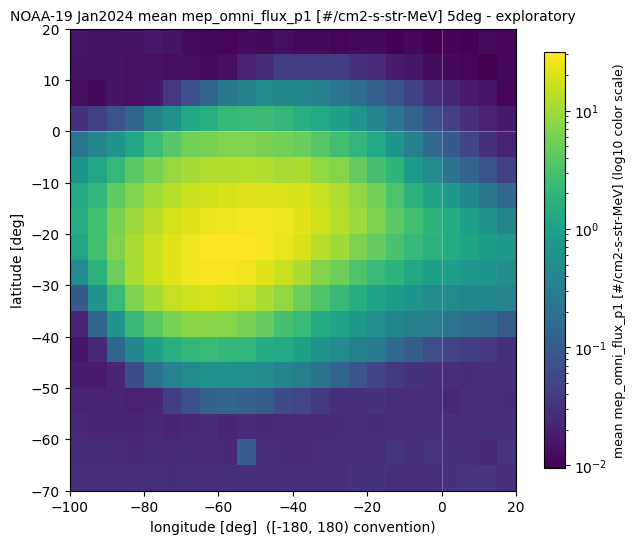

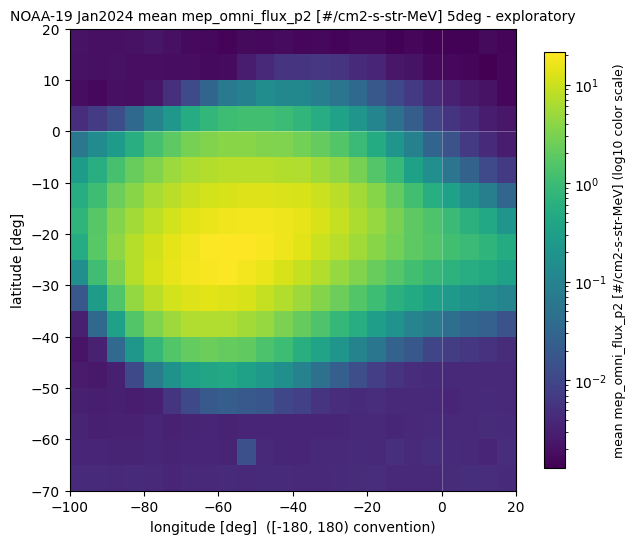

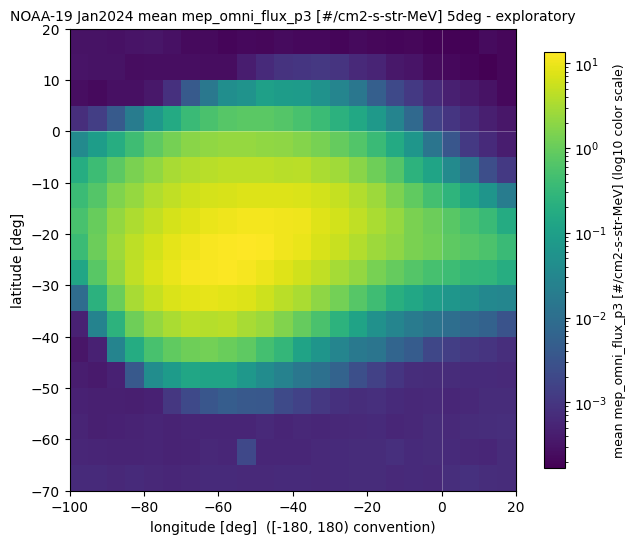

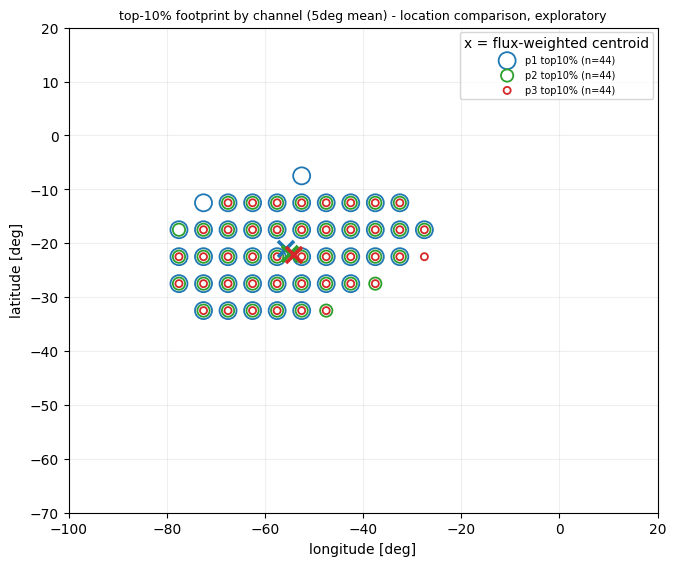

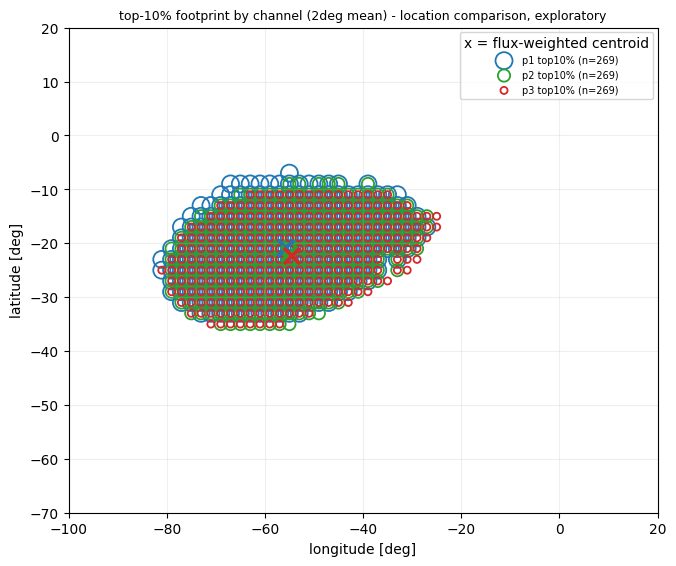

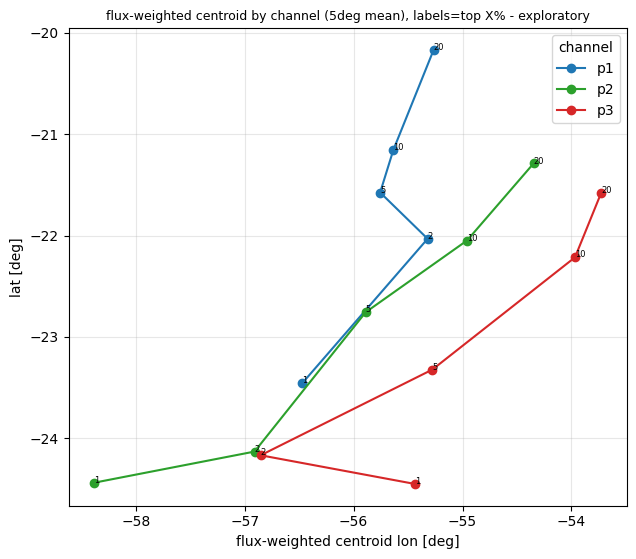

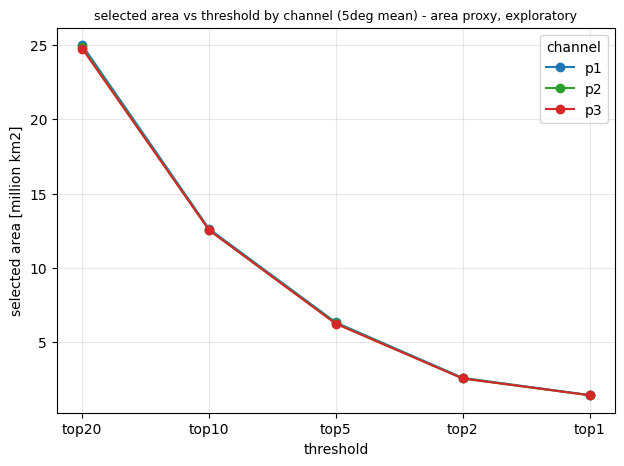

saved CP4C figures (3 maps + 2 overlays + centroid + area)


In [7]:
def coverage_masked(g, thr):
    gm = copy.deepcopy(g); gm.mean = gm.mean.copy(); gm.median = gm.median.copy()
    bad = gm.count < thr; gm.mean[bad] = np.nan; gm.median[bad] = np.nan
    return gm

# A) per-channel mean flux maps (5deg)
for c in CHANNELS:
    g = coverage_masked(grid_statistics(region, c, 5.0, 5.0, LAT, LON), THRESH)
    plot_heatmap(g, "mean", title="NOAA-19 Jan2024 mean %s [%s] 5deg - exploratory" % (c, META[c]["units"]),
                 save_path=str(FIG / f"cp4c_noaa19_2024-01_{SHORT[c]}_mean_flux_5deg.png"))

# B) top-10% footprint overlay comparison (channels together)
def channel_overlay(tables, mask_col, pct, save, title):
    fig, ax = plt.subplots(figsize=(7.6, 6.3))
    for c in CHANNELS:
        cov = coverage_passed(tables[c], mask_col)
        cut = percentile_threshold(cov["mean_flux"], pct)
        sel = cov[cov["mean_flux"] >= cut]
        ax.scatter(sel.lon_bin_center, sel.lat_bin_center, s=SIZES[c], facecolors="none",
                   edgecolors=COLORS[c], linewidths=1.3, label="%s top10%% (n=%d)" % (SHORT[c], len(sel)))
        wlat, wlon = flux_weighted_centroid(sel, "mean_flux")
        ax.plot(wlon, wlat, marker="x", color=COLORS[c], ms=11, mew=2.6)
    ax.set_xlim(LON[0], LON[1]); ax.set_ylim(LAT[0], LAT[1]); ax.grid(alpha=0.2)
    ax.set_xlabel("longitude [deg]"); ax.set_ylabel("latitude [deg]")
    ax.set_title(title, fontsize=9); ax.legend(fontsize=7, title="x = flux-weighted centroid")
    fig.savefig(save, dpi=120, bbox_inches="tight")

channel_overlay(grids5, "enough_samples_5deg", 90, str(FIG / "cp4c_channel_comparison_top10_5deg_mean.png"),
                "top-10% footprint by channel (5deg mean) - location comparison, exploratory")
channel_overlay(grids2, "enough_samples_2deg", 90, str(FIG / "cp4c_channel_comparison_top10_2deg_mean.png"),
                "top-10% footprint by channel (2deg mean) - location comparison, exploratory")

# C) flux-weighted centroid comparison across channels (5deg mean)
fig, ax = plt.subplots(figsize=(7.2, 6.2))
for c in CHANNELS:
    sub = sens[(sens.channel == c) & (sens.grid_deg == 5) & (sens.statistic_used == "mean_flux")].sort_values("percentile_cutoff")
    ax.plot(sub.centroid_lon_flux_weighted, sub.centroid_lat_flux_weighted, marker="o", color=COLORS[c], label=SHORT[c])
    for _, r in sub.iterrows():
        ax.annotate(r.threshold_label.replace("top", ""), (r.centroid_lon_flux_weighted, r.centroid_lat_flux_weighted), fontsize=6)
ax.set_xlabel("flux-weighted centroid lon [deg]"); ax.set_ylabel("lat [deg]"); ax.grid(alpha=0.3)
ax.set_title("flux-weighted centroid by channel (5deg mean), labels=top X% - exploratory", fontsize=9)
ax.legend(title="channel"); fig.savefig(str(FIG / "cp4c_channel_centroid_comparison.png"), dpi=120, bbox_inches="tight")

# D) selected area vs threshold by channel (5deg mean)
order = ["top20", "top10", "top5", "top2", "top1"]
fig, ax = plt.subplots(figsize=(7.2, 5.0))
for c in CHANNELS:
    sub = sens[(sens.channel == c) & (sens.grid_deg == 5) & (sens.statistic_used == "mean_flux")].set_index("threshold_label").loc[order]
    ax.plot(order, sub.selected_area_km2 / 1e6, marker="o", color=COLORS[c], label=SHORT[c])
ax.set_xlabel("threshold"); ax.set_ylabel("selected area [million km2]"); ax.grid(alpha=0.3)
ax.set_title("selected area vs threshold by channel (5deg mean) - area proxy, exploratory", fontsize=9)
ax.legend(title="channel"); fig.savefig(str(FIG / "cp4c_channel_area_by_threshold.png"), dpi=120, bbox_inches="tight")

plt.show()
print("saved CP4C figures (3 maps + 2 overlays + centroid + area)")

## Summary (exploratory)

Same-method monthly footprints for proton channels p1/p2/p3 (25/50/100 MeV per NetCDF `long_name`).
We report **channel-dependent footprint** location/area; absolute intensity is **not** compared across
channels (energy-dependent). This is **channel sensitivity**, **not** a final SAA boundary, dose,
danger, or discovery. Validate with `python scripts/validate_cp4c_outputs.py`.

Next: satellite and time-window sensitivity; only later a magnetic-coordinate (IGRF) framing.